# Task 1: Vectorized Multi-Layer Perceptron (MLP) Forward & Backward Pass from Scratch

**Objective:** Master the mathematical foundations of gradient descent by deriving and implementing multi-layer backpropagation equations using raw matrix calculus from first principles.

### Mathematical Formulation

#### Forward Pass
For a layer $l$ with weight matrix $W^{[l]}$ and bias vector $b^{[l]}$:
$$Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}$$
$$A^{[l]} = g^{[l]}(Z^{[l]})$$

#### Backward Pass (Vectorized)
Let the loss be $L$. We compute gradients backward from the output layer $L$ to the input layer $1$:
1. Output gradient w.r.t logits (for Softmax + Cross Entropy):
   $$dZ^{[L]} = A^{[L]} - Y$$
2. Gradient w.r.t weights and biases of layer $l$:
   $$dW^{[l]} = \frac{1}{m} A^{[l-1]\top} dZ^{[l]}$$
   $$db^{[l]} = \frac{1}{m} \sum_{i=1}^{m} dZ^{[l]}_i$$
3. Gradient w.r.t activation of preceding layer:
   $$dA^{[l-1]} = dZ^{[l]} W^{[l]\top}$$
4. Gradient w.r.t logits of preceding layer:
   $$dZ^{[l-1]} = dA^{[l-1]} \odot g^{[l-1]\prime}(Z^{[l-1]})$$
   where $\odot$ represents the Hadamard (element-wise) product and $g^\prime$ is the activation derivative.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Activation Functions and their Derivatives
def relu(x):
    # ReLU activation function
    return np.maximum(0, x)

def relu_derivative(x):
    # Derivative of ReLU activation function
    return (x > 0).astype(float)

def sigmoid(x):
    # Sigmoid activation function
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    # Derivative of Sigmoid activation function
    s = sigmoid(x)
    return s * (1 - s)

def stable_softmax(x):
    # Softmax activation function with subtraction of max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

class DenseLayer:
    def __init__(self, input_dim, output_dim, activation='relu'):
        # Initialize weights using Xavier/Glorot normal distribution
        self.W = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / (input_dim + output_dim))
        self.b = np.zeros((1, output_dim))
        
        self.activation = activation
        self.X_cache = None
        self.Z_cache = None
        
        # Gradient accumulators
        self.dW = None
        self.db = None
        
    def forward(self, X):
        # Forward pass: store caches for backpropagation
        self.X_cache = X
        self.Z_cache = np.dot(X, self.W) + self.b
        
        if self.activation == 'relu':
            return relu(self.Z_cache)
        elif self.activation == 'sigmoid':
            return sigmoid(self.Z_cache)
        elif self.activation == 'softmax':
            return stable_softmax(self.Z_cache)
        else:
            return self.Z_cache
            
    def backward(self, dA):
        # Backward pass: compute local derivatives and gradients w.r.t parameters
        m = self.X_cache.shape[0]
        
        # Compute dZ = dLoss/dZ
        if self.activation == 'relu':
            dZ = dA * relu_derivative(self.Z_cache)
        elif self.activation == 'sigmoid':
            dZ = dA * sigmoid_derivative(self.Z_cache)
        elif self.activation == 'softmax':
            # softmax is handled in junction with cross-entropy in the loss layer
            dZ = dA
        else:
            dZ = dA
            
        # Compute gradients w.r.t parameters
        self.dW = np.dot(self.X_cache.T, dZ) / m
        self.db = np.sum(dZ, axis=0, keepdims=True) / m
        
        # Return dA_prev to propagate back to previous layers
        dA_prev = np.dot(dZ, self.W.T)
        return dA_prev

class MLPClassifier:
    def __init__(self, layer_sizes, activations):
        self.layers = []
        for i in range(len(layer_sizes) - 1):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i+1], activations[i]))
            
    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out
        
    def backward(self, Y_pred, Y_true):
        m = Y_true.shape[0]
        # The gradient of cross entropy loss w.r.t logits of a final softmax layer is (Y_pred - Y_true)
        dA = Y_pred - Y_true
        
        # Backpropagate through layers in reverse order
        for layer in reversed(self.layers):
            dA = layer.backward(dA)
            
    def update_weights(self, lr):
        # Standard Gradient Descent Weight Updates
        for layer in self.layers:
            layer.W -= lr * layer.dW
            layer.b -= lr * layer.db

Epoch    0 | Cross Entropy Loss: 1.1161 | Accuracy: 10.22%
Epoch  200 | Cross Entropy Loss: 0.1572 | Accuracy: 96.22%
Epoch  400 | Cross Entropy Loss: 0.0613 | Accuracy: 97.78%
Epoch  600 | Cross Entropy Loss: 0.0419 | Accuracy: 98.44%
Epoch  800 | Cross Entropy Loss: 0.0331 | Accuracy: 98.89%
Epoch 1000 | Cross Entropy Loss: 0.0302 | Accuracy: 98.89%
Epoch 1200 | Cross Entropy Loss: 0.0260 | Accuracy: 99.11%
Epoch 1400 | Cross Entropy Loss: 0.0244 | Accuracy: 99.33%
Epoch 1600 | Cross Entropy Loss: 0.0233 | Accuracy: 99.33%
Epoch 1800 | Cross Entropy Loss: 0.0238 | Accuracy: 98.89%


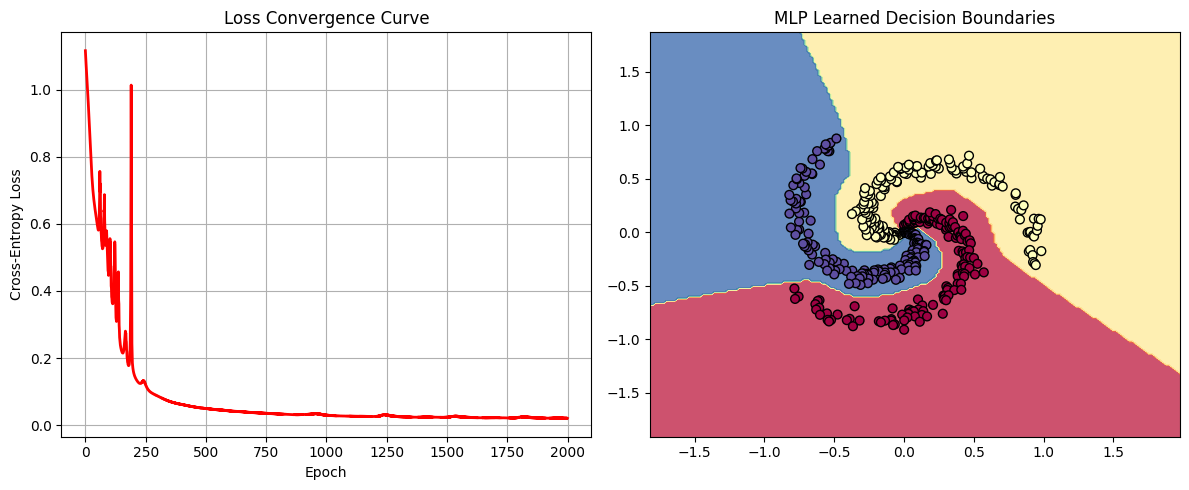

In [2]:
# Synthetic data generator: Spiral Dataset
def generate_spiral_data(points_per_class=100, classes=3):
    N = points_per_class
    D = 2
    K = classes
    X = np.zeros((N * K, D))
    y = np.zeros(N * K, dtype='uint8')
    for j in range(K):
        ix = range(N * j, N * (j + 1))
        r = np.linspace(0.0, 1, N) # radius
        t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2 # theta
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    
    # Convert to one-hot encoding
    Y_onehot = np.zeros((N * K, K))
    Y_onehot[np.arange(N * K), y] = 1
    return X, y, Y_onehot

X, y, Y = generate_spiral_data(points_per_class=150, classes=3)

# Initialize 3-layer MLP
# 2 inputs -> 64 hidden units (ReLU) -> 32 hidden units (ReLU) -> 3 outputs (Softmax)
mlp = MLPClassifier([2, 64, 32, 3], ['relu', 'relu', 'softmax'])

# Train network
epochs = 2000
lr = 0.5
loss_history = []

for epoch in range(epochs):
    # Forward pass
    probs = mlp.forward(X)
    
    # Calculate categorical cross-entropy loss
    loss = -np.mean(np.sum(Y * np.log(probs + 1e-15), axis=-1))
    loss_history.append(loss)
    
    # Backward pass
    mlp.backward(probs, Y)
    
    # Weights adjustments
    mlp.update_weights(lr)
    
    if epoch % 200 == 0:
        accuracy = np.mean(np.argmax(probs, axis=-1) == y)
        print(f"Epoch {epoch:4d} | Cross Entropy Loss: {loss:.4f} | Accuracy: {accuracy*100:.2f}%")

# Plotting results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, 'r-', lw=2)
plt.title('Loss Convergence Curve')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
# Plot decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = np.argmax(mlp.forward(grid_points), axis=-1)
grid_preds = grid_preds.reshape(xx.shape)
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors='k')
plt.title('MLP Learned Decision Boundaries')
plt.tight_layout()
plt.show()